In [1]:
library(enrichplot)
library(DOSE)
library(clusterProfiler)
library(msigdbr)
library(openxlsx)
library(dplyr)
library(tximport)
library(readr)
library(tximportData)
library(GenomicFeatures)
library(ggplot2)
library(ape)
library(stringr)
library(fgsea)
library(pheatmap)



DOSE v3.28.2  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use DOSE in published research, please cite:
Guangchuang Yu, Li-Gen Wang, Guang-Rong Yan, Qing-Yu He. DOSE: an R/Bioconductor package for Disease Ontology Semantic and Enrichment analysis. Bioinformatics 2015, 31(4):608-609


clusterProfiler v4.10.1  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading

## D30 GSEA

In [4]:
library(openxlsx)
library(dplyr)
library(clusterProfiler)
library(ggplot2)

# Read data
annotated_peaks <- readRDS("/mnt/d/Projects/Fuchs/annotated_peaks.rds")
all_info <- read.xlsx('/mnt/c/Users/sotougl/Downloads/D30_6hTPA_PIMQvCtrl_DESeq2_full_res.xlsx')
colnames(all_info)[3] <- 'symbol'

# Extract gene sets from annotated_peaks
lt_genes <- unique(annotated_peaks$lt_memory$SYMBOL)
st_genes <- unique(annotated_peaks$st_memory$SYMBOL)
non_st_memory <- annotated_peaks$memory[!(annotated_peaks$memory %over% annotated_peaks$st_memory)]
st_genes <- unique(annotated_peaks$st_memory$SYMBOL[!(annotated_peaks$st_memory$SYMBOL %in% non_st_memory$SYMBOL)])
memory_genes <- unique(annotated_peaks$memory$SYMBOL)
resolved_genes <- unique(annotated_peaks$resolved$SYMBOL)
unchanged_genes <- unique(annotated_peaks$unchanged$SYMBOL)


baseMean_thresholds <- 20

# Initialize results data frame
results_df <- data.frame(
  baseMean_threshold = numeric(),
  n_genes = integer(),
  pathway = character(),
  pvalue = numeric(),
  padj = numeric(),
  stringsAsFactors = FALSE
)

# Loop through different baseMean thresholds
for (threshold in baseMean_thresholds) {
  
  # Filter data by current threshold
  filtered_data <- all_info %>% filter(baseMean > threshold)
  n_genes <- nrow(filtered_data)
  
  # Create gene ranking
  Ranks <- filtered_data$log2FoldChange
  names(Ranks) <- filtered_data$symbol
  Ranks <- sort(Ranks, decreasing = TRUE)
  
  # Get genes present in current filtered dataset for each gene set
  lt_genes_present <- intersect(lt_genes, names(Ranks))
  st_genes_present <- intersect(st_genes, names(Ranks))
  memory_genes_present <- intersect(memory_genes, names(Ranks))
  resolved_genes_present <- intersect(resolved_genes, names(Ranks))
  unchanged_genes_present <- intersect(unchanged_genes, names(Ranks))
  
  # Create list of gene sets with their sizes
  gene_sets_list <- list(
    Long_term = lt_genes_present,
    Short_term = st_genes_present,
    All_memory = memory_genes_present,
    Resolved = resolved_genes_present,
    Unchanged = unchanged_genes_present
  )
  
  # Filter out gene sets with less than 10 genes
  gene_sets_list <- gene_sets_list[sapply(gene_sets_list, length) >= 10]
  
  # Build TERM2GENE data frame with all gene sets
  msigdb_term2gene <- do.call(rbind, lapply(names(gene_sets_list), function(pathway_name) {
    data.frame(
      term = pathway_name,
      gene = gene_sets_list[[pathway_name]],
      stringsAsFactors = FALSE
    )
  }))
  
  # Run GSEA
  tryCatch({
    gseaResults <- GSEA(
      geneList      = Ranks,
      TERM2GENE     = msigdb_term2gene,
      pvalueCutoff  = 0.99,
      pAdjustMethod = "BH",
      nPermSimple   = 10000,
      minGSSize     = 10,
      maxGSSize     = 1000,
      verbose       = FALSE
    )
    
    # Extract results
    gsea_df <- as.data.frame(gseaResults)
    
    if (nrow(gsea_df) > 0) {
      for (i in 1:nrow(gsea_df)) {
        results_df <- rbind(results_df, data.frame(
          baseMean_threshold = threshold,
          n_genes = n_genes,
          pathway = gsea_df$ID[i],
          pvalue = gsea_df$pvalue[i],
          padj = gsea_df$p.adjust[i],
          stringsAsFactors = FALSE
        ))
      }
    }
  }, error = function(e) {
    message(paste("Error at threshold", threshold, ":", e$message))
  })
  
  message(paste("Completed threshold:", threshold, "| n_genes:", n_genes))
}

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.01% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are duplicate gene names, fgsea may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”
Completed threshold: 20 | n_genes: 12132



In [5]:
print(length(lt_genes_present))
print(length(st_genes_present))

print(length(lt_genes))
print(length(st_genes))

[1] 84
[1] 48
[1] 112
[1] 68


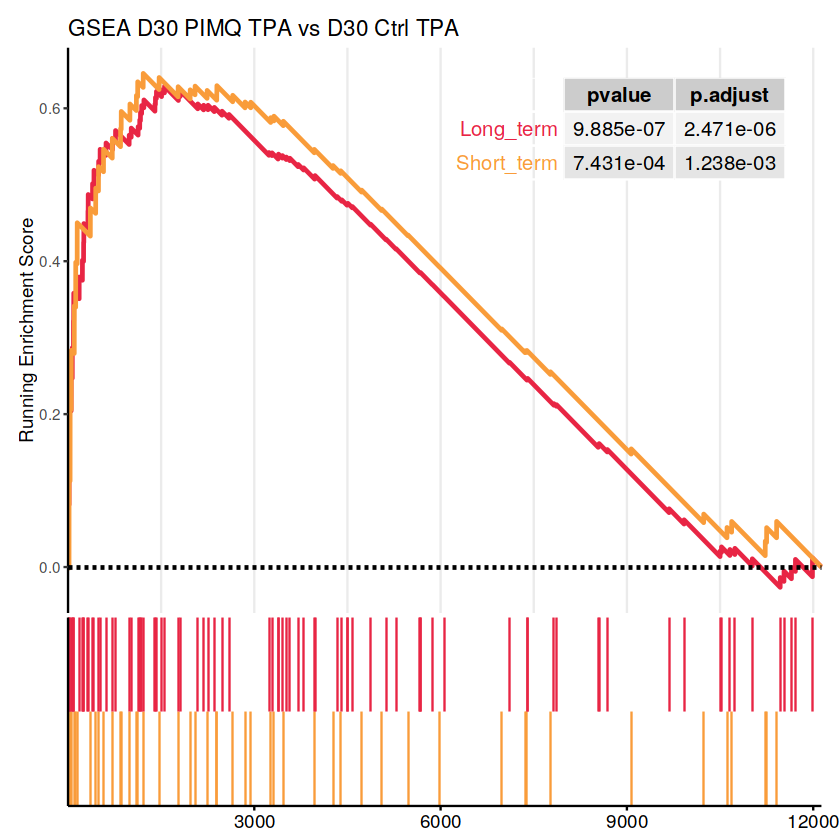

In [6]:
p <- gseaplot2(gseaResults, 
               geneSetID = c("Short_term", "Long_term"),
               title = "GSEA D30 PIMQ TPA vs D30 Ctrl TPA",
               color = c("#e82544", "#f99c3a"), subplots = c(1,2),
               pvalue_table = TRUE)

# Agregar línea horizontal en y=0 al primer panel (Enrichment Score)
p[[1]] <- p[[1]] + geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1)

# Mostrar el plot
print(p)

In [7]:
as.data.frame(gseaResults)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<chr>,<chr>
All_memory,All_memory,All_memory,523,0.5626797,2.237447,1.000000e-10,5.000000e-10,NA,1636,"tags=33%, list=13%, signal=29%",Hand1/9330188P03Rik/Cyp7b1/Rnase2b/Sema6d/Lgi2/Srgn/Aim2/Eps8/Tnfaip2/Tmprss11g/Pi15/Piwil2/Arc/Rgcc/Samd12/Il18/Ccl2/Cotl1/Vav1/Pitpnm3/Sox5/Nceh1/Cdhr1/Dkk3/Trps1/Mettl7a1/Cacna2d3/Casp1/Ppm1l/Stc2/B3gnt3/Syne1/Mfap3l/2610528A11Rik/Procr/Casp12/Rps6ka5/Cemip/Dock8/Glrx/Sorl1/Dap/Efnb2/Flt1/Prss12/Fetub/C430042M11Rik/Nppb/0610040F04Rik/Klhl29/Enpp1/Bfsp1/Mtss1/E2f7/Lipn/Epas1/Hrh1/Tfdp2/Zfp36l2/Klf7/Ube2cbp/Fmnl2/Adtrp/Kif1a/Mylip/Psap/Adrb1/Frmd4a/Slc10a6/Dock4/Htr1b/Reep6/Bcl11a/5830432E09Rik/Ly6c2/Mpzl1/Irx3/Jcad/Igf2bp2/Abcc5/Pbx1/Stox2/Cald1/Trim8/Glis1/Lmnb1/Pik3r1/1700030K09Rik/Sgk1/Rassf6/Shroom3/Arhgef10/Ntng2/Bbs9/Robo2/Barx2/Ltbp4/Arhgap25/Plekhh2/Cyp2g1/Klf4/Thbs2/Fos/Pnp2/Hs3st1/Gdpd5/Dhcr24/Ltbp1/Ly6a/Etv5/Pdxk/Has3/St7/Nr3c1/Id1/Lratd2/Tnrc18/B4galnt4/Impa2/Incenp/Myof/Odc1/Foxp1/Slc39a11/Arhgap18/Slc22a18/Macrod2/Il33/Impdh1/Man2a1/Nfil3/Nln/Mapk6/Ric8b/Xdh/Armc6/Sorcs2/Atg4c/Lrrc20/Abcc4/Errfi1/Ly6e/Gm49890/Sdccag8/Sdhd/Runx1/Ets2/Kank1/Mettl14/Nin/Pitrm1/Jarid2/Tcirg1/Slc4a7/C2cd5/Pts/Abl2/Tpbg/Hivep2/Cpne8/Cdk17/Degs1/Cdc42ep4/Pmepa1/Casp4/Ank/Sorbs1/Cep128/Nphp4
Long_term,Long_term,Long_term,84,0.6287749,2.074432,9.885019e-07,2.471255e-06,NA,1555,"tags=38%, list=13%, signal=33%",Rnase2b/Lgi2/Aim2/Arc/Il18/Pitpnm3/Sox5/Rps6ka5/Prss12/Fetub/C430042M11Rik/Mtss1/E2f7/Klf7/Adtrp/Reep6/Mpzl1/Glis1/Robo2/Klf4/Nr3c1/Lratd2/Man2a1/Nfil3/Nln/Mapk6/Armc6/Kank1/Mettl14/Pitrm1/Tpbg/Cdk17
Short_term,Short_term,Short_term,48,0.6456504,1.945132,7.430901e-04,1.238484e-03,NA,1212,"tags=35%, list=10%, signal=32%",Sema6d/Pi15/Rgcc/Cdhr1/B3gnt3/Procr/Tfdp2/Psap/Htr1b/Abcc5/Ntng2/Gdpd5/Ly6a/Id1/Macrod2/Impdh1/Xdh
Resolved,Resolved,Resolved,580,0.3425987,1.372111,1.985517e-03,2.481897e-03,NA,1796,"tags=22%, list=15%, signal=19%",Kcnh1/Gas1/Pi15/Tie1/Nr4a2/Cers4/P2rx7/Rgs3/Gfra1/Steap4/Syne1/Fam20c/Ntf3/Tmem131l/Adcy9/Angptl2/Stfa3/Glrx/Efnb2/Myo1b/Fcmr/Ednra/Ccn1/Foxq1/Rnf144b/Cenpf/Sox6/Txndc16/Ube2cbp/Flvcr2/Ccnd1/Nfia/Slc10a6/Sesn3/Bcl11a/Nr4a3/Fam178b/Zfp365/Acta2/Myc/Shtn1/Morrbid/Gjb6/Slc25a42/Ptprs/Celsr1/Shroom3/Arhgap25/Fos/Slc26a4/Rnf165/Dglucy/Pnp2/Hs3st1/Wnk2/Ifitm10/Dhcr7/Arntl2/Phlda1/Slc39a14/Has3/Enah/Il1rap/St7/Nr3c1/Pitpnc1/Polr3gl/Mitf/Psen2/Ttll5/Tfap2b/Nfic/Stk39/Slc39a11/Macrod2/Aff3/Mmp2/Ociad2/Kcnj15/Egr4/Rflnb/Cdca7/Kitl/Plek2/Sorcs2/Atp1a1/Hoxc4/Pld1/Tsku/Prkdc/Myzap/Tram2/Casp14/Sh3kbp1/Cavin1/Vrk2/Eef1aknmt/Wdpcp/Kank1/Ppt1/Mrc2/Pitrm1/Tmem241/Jarid2/Phf21b/Dhrs3/Il4ra/Prkcz/Rpia/Mex3b/Lce1m/Ampd3/Dtl/Arhgef10l/Rhobtb3/Iqsec1/Chsy1/Rapgef4/Inpp1/Slc25a26/Prkca/Nfib/Ninl/Il20rb/Vav3/Pip4k2b
Unchanged,Unchanged,Unchanged,604,0.3335589,1.338611,3.602138e-03,3.602138e-03,NA,1785,"tags=21%, list=15%, signal=19%",Adh7/Npr3/Lgr6/Batf2/Nr4a2/Maf/Duoxa1/Rgs3/Stab1/Adrb2/Sh2b2/Thsd4/Dock8/Glrx/Sorl1/Dap/Ccnb2/Hic2/Lce3f/Slc6a6/Areg/Hmgcll1/Tsc22d3/Ska1/Gbp2/Gli2/Cyp2w1/Igfbp4/Rnf144b/Slc1a3/Dst/Nfia/Mylip/Snx24/Sesn3/Ptprk/Mpzl1/Tbc1d8/Klhl17/Mgst2/Tex14/Eid2/Pik3r1/Morrbid/Sms/Lamb3/Tcf7/Bmp7/Sgk1/Fscn1/Dhrs9/Fry/Trnp1/Anxa6/Dusp9/Hmcn1/Robo2/Btbd11/Aadac/Lysmd2/Zbtb38/Lypd6b/Prkcq/Col4a6/Etv5/Col4a5/B3gnt2/Cep250/Gm20744/Vwa5a/Samhd1/Bcl2l11/Exoc6/Dlgap5/Pitpnc1/Mitf/Irx5/Nthl1/Chst3/Nfic/Kcnj2/Odc1/Tns1/Arl4c/Macrod2/Paqr5/Acaa2/Aff3/Apcdd1/Ociad2/Acot7/Nudt14/D630033O11Rik/Atp8a1/Plek2/Plaur/Il18r1/Mrpl42/Tle5/Tmsb4x/Ets2/Itm2b/Tenm4/Wdpcp/Pitrm1/Dipk1a/Trerf1/Jarid2/Slc4a7/Dusp1/Phf21b/Ergic1/Gpn3/Trp63/Clmn/Gfod1/Plxdc2/Jag1/Prom2/Lncppara/Cntrob/Aopep/Ptger2/Acss1/Lrrc8d/Vav3/Rabgap1l


In [246]:
ggsave('D30_GSEA.pdf', p, height = 4, width = 6)

## Y1 GSEA

In [18]:
library(openxlsx)
library(dplyr)
library(clusterProfiler)
library(ggplot2)

# Read data
annotated_peaks <- readRDS("/mnt/d/Projects/Fuchs/annotated_peaks.rds")
all_info <- read.xlsx('/mnt/c/Users/sotougl/Downloads/1Y_6hTPA_PIMQvCtrl_DESeq2_full_res.xlsx')
colnames(all_info)[3] <- 'symbol'

# Extract gene sets from annotated_peaks
lt_genes <- unique(annotated_peaks$lt_memory$SYMBOL)
st_genes <- unique(annotated_peaks$st_memory$SYMBOL)
length(lt_genes)
length(st_genes)

non_st_memory <- annotated_peaks$memory[!(annotated_peaks$memory %over% annotated_peaks$st_memory)]
st_genes <- unique(annotated_peaks$st_memory$SYMBOL[!(annotated_peaks$st_memory$SYMBOL %in% non_st_memory$SYMBOL)])
length(st_genes)
memory_genes <- unique(annotated_peaks$memory$SYMBOL)
resolved_genes <- unique(annotated_peaks$resolved$SYMBOL)
unchanged_genes <- unique(annotated_peaks$unchanged$SYMBOL)


# Define baseMean thresholds to test 50
baseMean_thresholds <- c(20)

# Initialize results data frame
results_df <- data.frame(
  baseMean_threshold = numeric(),
  n_genes = integer(),
  pathway = character(),
  pvalue = numeric(),
  padj = numeric(),
  stringsAsFactors = FALSE
)

# Loop through different baseMean thresholds
for (threshold in baseMean_thresholds) {
  
  # Filter data by current threshold
  filtered_data <- all_info %>% filter(baseMean > threshold)
  n_genes <- nrow(filtered_data)
  
  # Skip if too few genes
  if (n_genes < 100) next
  
  # Create gene ranking
  Ranks <- filtered_data$log2FoldChange
  names(Ranks) <- filtered_data$symbol
  Ranks <- sort(Ranks, decreasing = TRUE)
  
  # Get genes present in current filtered dataset for each gene set
  lt_genes_present <- intersect(lt_genes, names(Ranks))
  st_genes_present <- intersect(st_genes, names(Ranks))
  memory_genes_present <- intersect(memory_genes, names(Ranks))
  resolved_genes_present <- intersect(resolved_genes, names(Ranks))
  unchanged_genes_present <- intersect(unchanged_genes, names(Ranks))
  
  # Create list of gene sets with their sizes
  gene_sets_list <- list(
    Long_term = lt_genes_present,
    Short_term = st_genes_present,
    All_memory = memory_genes_present,
    Resolved = resolved_genes_present,
    Unchanged = unchanged_genes_present
  )
  
  # Filter out gene sets with less than 10 genes
  gene_sets_list <- gene_sets_list[sapply(gene_sets_list, length) >= 10]
  
  # Skip if no valid gene sets
  if (length(gene_sets_list) == 0) next
  
  # Build TERM2GENE data frame with all gene sets
  msigdb_term2gene <- do.call(rbind, lapply(names(gene_sets_list), function(pathway_name) {
    data.frame(
      term = pathway_name,
      gene = gene_sets_list[[pathway_name]],
      stringsAsFactors = FALSE
    )
  }))
  
  # Run GSEA
  tryCatch({
    gseaResults <- GSEA(
      geneList      = Ranks,
      TERM2GENE     = msigdb_term2gene,
      pvalueCutoff  = 0.99,
      pAdjustMethod = "BH",
      nPermSimple   = 10000,
      minGSSize     = 10,
      maxGSSize     = 1000,
      verbose       = FALSE
    )
    
    # Extract results
    gsea_df <- as.data.frame(gseaResults)
    
    if (nrow(gsea_df) > 0) {
      for (i in 1:nrow(gsea_df)) {
        results_df <- rbind(results_df, data.frame(
          baseMean_threshold = threshold,
          n_genes = n_genes,
          pathway = gsea_df$ID[i],
          pvalue = gsea_df$pvalue[i],
          padj = gsea_df$p.adjust[i],
          stringsAsFactors = FALSE
        ))
      }
    }
  }, error = function(e) {
    message(paste("Error at threshold", threshold, ":", e$message))
  })
  
  message(paste("Completed threshold:", threshold, "| n_genes:", n_genes))
}

[1] 112

[1] 104

[1] 68

Completed threshold: 20 | n_genes: 12718



In [19]:
print(length(lt_genes_present))
print(length(st_genes_present))

print(length(lt_genes))
print(length(st_genes))


[1] 86
[1] 51
[1] 112
[1] 68


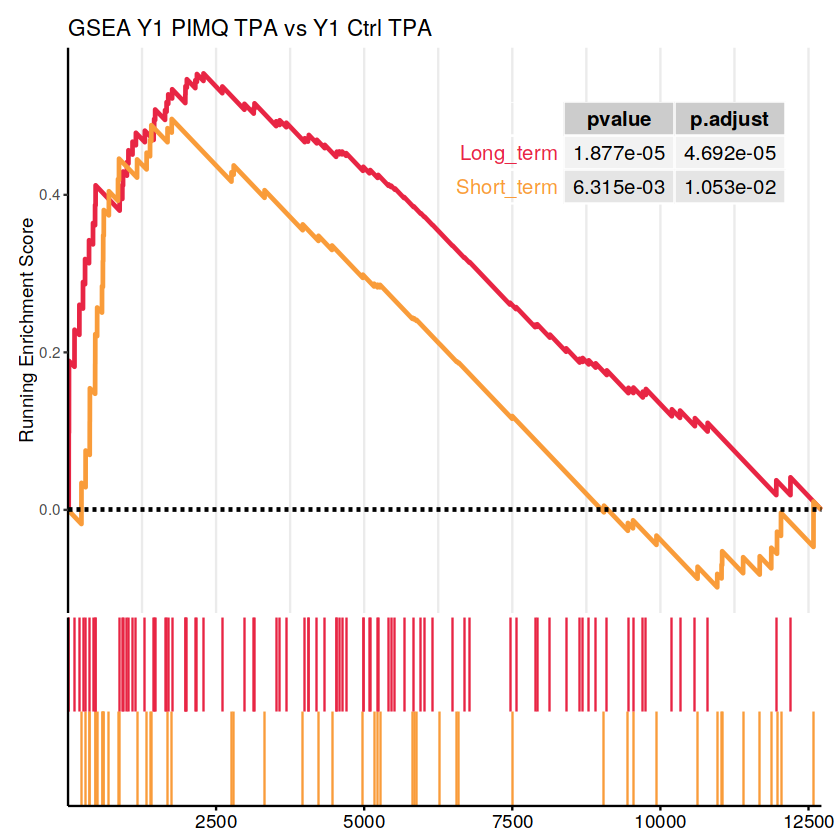

In [20]:
p <- gseaplot2(gseaResults, 
               geneSetID = c("Short_term", "Long_term"),
               title = "GSEA Y1 PIMQ TPA vs Y1 Ctrl TPA",
               color = c("#e82544", "#f99c3a"), subplots = c(1,2),
               pvalue_table = TRUE)

# Agregar línea horizontal en y=0 al primer panel (Enrichment Score)
p[[1]] <- p[[1]] + geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1)

# Mostrar el plot
print(p)

In [21]:
as.data.frame(gseaResults)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
All_memory,All_memory,All_memory,537,0.4003529,1.837040,2.244325e-10,1.122162e-09,4.724894e-10,2214,"tags=28%, list=17%, signal=24%",Hand1/Aim2/Rnase2b/Dct/Srgn/Adamtsl1/Cd302/Samd12/Tgfb3/Plekhh2/Mroh4/Il18/Trpv1/Gm9530/A530013C23Rik/Abca4/Tmem45b/Clec2g/Rgcc/Basp1/Evl/Adgrb1/Glis1/Oas3/Map2k6/Ccl2/Scd1/Enpp1/Gipc2/Gdpd5/Cfap45/Klf10/Nr1d2/Piwil2/0610040F04Rik/Elovl5/Robo2/Bcat1/Chd9/Tnfsf13/Fetub/Htr1b/Icosl/Cdhr1/Tfdp2/Msmo1/Nedd9/Casp4/Vgll3/Cd209c/Tent5c/Klkb1/Tmem263/Zfhx3/Nemp2/Errfi1/Ly6a/Klf12/Klf7/Btg1/Ikzf2/Adtrp/Prdm1/Lpin1/Lratd2/Ptk2b/Tnfsf18/Sec11c/Pmaip1/Sorl1/Il33/Gm31763/Rabl2/Sox5/Wsb1/Rbpms/Mpzl1/Acvr2a/Pik3r1/Pdlim5/Casp1/Dgkh/Kctd4/Slc10a6/Mapk6/Agpat4/Sgk1/Daam1/Il10/Gm20257/Vmp1/Vps37b/Pnp2/Adgrl2/Procr/Abcc5/4930455G09Rik/Sdccag8/Ly6e/Cdk17/Nfil3/Gm49890/Rad21/Lpp/Fmnl2/Hivep2/Ppm1l/Rassf6/Syne1/Mtss1/Tmprss11g/Odc1/Zfp280d/Epb41l2/Sema6d/Arc/Srpk2/Ube2q2/Mfap3l/Slc4a7/Spidr/Fndc3a/A3galt2/Cttnbp2nl/Zfp3/Klf5/Tenm2/Cd44/Jmy/Lgi2/Snx10/Atg4c/Akr1e1/Rora/Jarid2/Stox2/Ank3/Bmpr2/Abl2/Plxna2/Spin1/Upf2/Arl15/Ptprj/Has2/Prps1/Elk4/Mirt1
Long_term,Long_term,Long_term,86,0.5542017,2.045742,1.876768e-05,4.691920e-05,1.975545e-05,2288,"tags=36%, list=18%, signal=30%",Aim2/Rnase2b/Il18/Clec2g/Adgrb1/Glis1/Gipc2/Robo2/Bcat1/Fetub/Klf7/Adtrp/Lratd2/Sox5/Mpzl1/Dgkh/Mapk6/Adgrl2/Cdk17/Nfil3/Rad21/Mtss1/Zfp280d/Arc/Spidr/Jmy/Lgi2/Snx10/Spin1/Arl15/Pex3
Short_term,Short_term,Short_term,51,0.4963337,1.669852,6.315410e-03,1.052568e-02,4.431866e-03,1752,"tags=39%, list=14%, signal=34%",Rgcc/Map2k6/Gdpd5/Klf10/Chd9/Tnfsf13/Htr1b/Cdhr1/Tfdp2/Msmo1/Nedd9/Cd209c/Ly6a/Klf12/Daam1/Procr/Abcc5/4930455G09Rik/Sema6d/Slc4a7
Resolved,Resolved,Resolved,605,0.2550396,1.180980,6.604451e-02,8.255564e-02,3.476027e-02,2106,"tags=21%, list=17%, signal=19%",Rflnb/Igfl3/Mfsd4b3-ps/Adgrl3/Rasgef1b/Tie1/A530013C23Rik/Kcnh1/Basp1/Emp1/Sgms2/Adgrb1/Sgip1/Oas3/Map2k6/Ackr2/Cd180/Gipc2/Ttc32/Adm/Map3k8/Psd3/Chd9/Nfat5/Myzap/Mturn/Pmp22/Cers4/Skil/Pde4b/Dpysl3/Rec114/Adgrv1/Ccng2/Zbed5-ps/Dennd2c/Trpm1/Zfhx3/Tef/Dapk1/Dnase1l3/Ntf3/Zbtb43/Ptbp2/Inpp1/Klf12/Tmcc3/Adamtsl3/Btg1/Creb5/Foxo3/Tcp11l2/Ptpru/Acvr2a/9530080O11Rik/Ankrd24/Fam133b/Kctd4/Ifi203/Arhgap26/Nr4a3/Zfp120/Slc10a6/Daam1/Il10/Edn1/F3/Slc6a14/Ednra/Zmym2/Pde4d/Mex3c/Pnp2/Hes1/Atg13/Dhx40/Kitl/Rb1cc1/Klf3/Usp47/Esyt2/Slc38a1/Defb1/Nrp1/Tra2a/Nr4a2/Raph1/Hs3st3b1/Fkbp5/Tcim/Sertad2/Tmem164/Acta2/Adcy6/Chp1/Plekhg1/Dusp16/Rbbp8/Syne1/BC005537/S100a11/Zfp280d/Specc1/Robo1/Plek2/Smad3/Slc38a2/Ptpn12/Zfp703/Utrn/Txndc16/P2rx7/Tead1/Ist1/Dipk1b/Slc30a4/Ttc33/Kansl1/Has2os/Numb/Ints6/Adnp2/Gnai3/Slc38a6/Sash1/Etfbkmt/Ube2h/Jarid2/Ank3/Ereg
Unchanged,Unchanged,Unchanged,616,0.2392036,1.109190,1.597073e-01,1.597073e-01,6.724517e-02,2111,"tags=19%, list=17%, signal=17%",Krt7/Hmcn1/Stx2/Sh2b2/Hic2/Fbp1/Gm9530/Tmem45b/3300002I08Rik/Emp1/Aadac/Apcdd1/Tsc22d3/Bcl2l11/Gipc2/Ly6m/Robo2/Chst3/Gbp2/Fam107b/Ifrd1/Npr3/Sc5d/Tmem170b/Icosl/Zscan30/Sez6l2/Ahnak/Zfp60/Dhrs9/Adrb2/Adgrv1/Csrp1/Dgki/Cep112/Nfatc1/Gm16863/Inpp4a/Lgr6/Sms/Marchf7/Gcnt4/Clmn/Btg2/Serpinb2/Creb5/Agfg2/Sorl1/Cpeb2/Fscn1/Mpzl1/Thsd4/Lekr1/Pik3r1/Slfn9/2010204K13Rik/Kctd4/Slc6a4/Slc6a6/Sgk1/Adh7/N4bp2l1/Prkx/Vwa5a/Plekhm3/Pde4d/Pls3/Helb/Vps37b/Anxa6/Gmpr/Msl3l2/Hes1/Ctbp2/Rasal2/Paqr5/Usp6nl/Lpp/Mzf1/Nr4a2/Tcim/Ar/Plaur/Rsbn1l/Pias1/Tmem164/Rps6ka3/Cidea/Pemt/Serpinb5/BC005537/Odc1/Plek2/Slc38a2/Rc3h1/Arid5b/Tlcd3a/Slc4a7/Tpm1/Ist1/Scmh1/Pard6b/Blcap/Elf4/N4bp2/Cd44/Numb/Wwtr1/Sumo2/Rassf5/Foxo1/Rora/Chaserr/Cdkl5/Jarid2/Trim2/Calm2


In [256]:
ggsave('Y1_GSEA.pdf', p, height = 4, width = 6)

# Y2 GSEA

In [9]:
library(openxlsx)
library(dplyr)
library(clusterProfiler)
library(ggplot2)

# Read data
annotated_peaks <- readRDS("/mnt/d/Projects/Fuchs/annotated_peaks.rds")
all_info <- read.xlsx('/mnt/c/Users/sotougl/Downloads/2Y_6hTPA_PIMQvCtrl_DESeq2_full_res (1).xlsx')
colnames(all_info)[3] <- 'symbol'

# Extract gene sets from annotated_peaks
lt_genes <- unique(annotated_peaks$lt_memory$SYMBOL)
st_genes <- unique(annotated_peaks$st_memory$SYMBOL)
non_st_memory <- annotated_peaks$memory[!(annotated_peaks$memory %over% annotated_peaks$st_memory)]
st_genes <- unique(annotated_peaks$st_memory$SYMBOL[!(annotated_peaks$st_memory$SYMBOL %in% non_st_memory$SYMBOL)])
memory_genes <- unique(annotated_peaks$memory$SYMBOL)
resolved_genes <- unique(annotated_peaks$resolved$SYMBOL)
unchanged_genes <- unique(annotated_peaks$unchanged$SYMBOL)


# Define baseMean thresholds to test 50
baseMean_thresholds <- c(20)

# Initialize results data frame
results_df <- data.frame(
  baseMean_threshold = numeric(),
  n_genes = integer(),
  pathway = character(),
  pvalue = numeric(),
  padj = numeric(),
  stringsAsFactors = FALSE
)

# Loop through different baseMean thresholds
for (threshold in baseMean_thresholds) {
  
  # Filter data by current threshold
  filtered_data <- all_info %>% filter(baseMean > threshold)
  n_genes <- nrow(filtered_data)
  
  # Create gene ranking
  Ranks <- filtered_data$log2FoldChange
  names(Ranks) <- filtered_data$symbol
  Ranks <- sort(Ranks, decreasing = TRUE)
  
  # Get genes present in current filtered dataset for each gene set
  lt_genes_present <- intersect(lt_genes, names(Ranks))
  st_genes_present <- intersect(st_genes, names(Ranks))
  memory_genes_present <- intersect(memory_genes, names(Ranks))
  resolved_genes_present <- intersect(resolved_genes, names(Ranks))
  unchanged_genes_present <- intersect(unchanged_genes, names(Ranks))
  
  # Create list of gene sets with their sizes
  gene_sets_list <- list(
    Long_term = lt_genes_present,
    Short_term = st_genes_present,
    All_memory = memory_genes_present,
    Resolved = resolved_genes_present,
    Unchanged = unchanged_genes_present
  )
  
  # Filter out gene sets with less than 10 genes
  gene_sets_list <- gene_sets_list[sapply(gene_sets_list, length) >= 10]

  
  # Build TERM2GENE data frame with all gene sets
  msigdb_term2gene <- do.call(rbind, lapply(names(gene_sets_list), function(pathway_name) {
    data.frame(
      term = pathway_name,
      gene = gene_sets_list[[pathway_name]],
      stringsAsFactors = FALSE
    )
  }))
  
  # Run GSEA
  tryCatch({
    gseaResults <- GSEA(
      geneList      = Ranks,
      TERM2GENE     = msigdb_term2gene,
      pvalueCutoff  = 0.99,
      pAdjustMethod = "BH",
      nPermSimple   = 10000,
      minGSSize     = 10,
      maxGSSize     = 1000,
      verbose       = FALSE
    )
    
    # Extract results
    gsea_df <- as.data.frame(gseaResults)
    
    if (nrow(gsea_df) > 0) {
      for (i in 1:nrow(gsea_df)) {
        results_df <- rbind(results_df, data.frame(
          baseMean_threshold = threshold,
          n_genes = n_genes,
          pathway = gsea_df$ID[i],
          pvalue = gsea_df$pvalue[i],
          padj = gsea_df$p.adjust[i],
          stringsAsFactors = FALSE
        ))
      }
    }
  }, error = function(e) {
    message(paste("Error at threshold", threshold, ":", e$message))
  })
  
  message(paste("Completed threshold:", threshold, "| n_genes:", n_genes))
}

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are duplicate gene names, fgsea may produce unexpected results.”
Completed threshold: 20 | n_genes: 11988



In [11]:
print(length(lt_genes_present))
print(length(st_genes_present))

print(length(lt_genes))
print(length(st_genes))

[1] 85
[1] 48
[1] 112
[1] 68


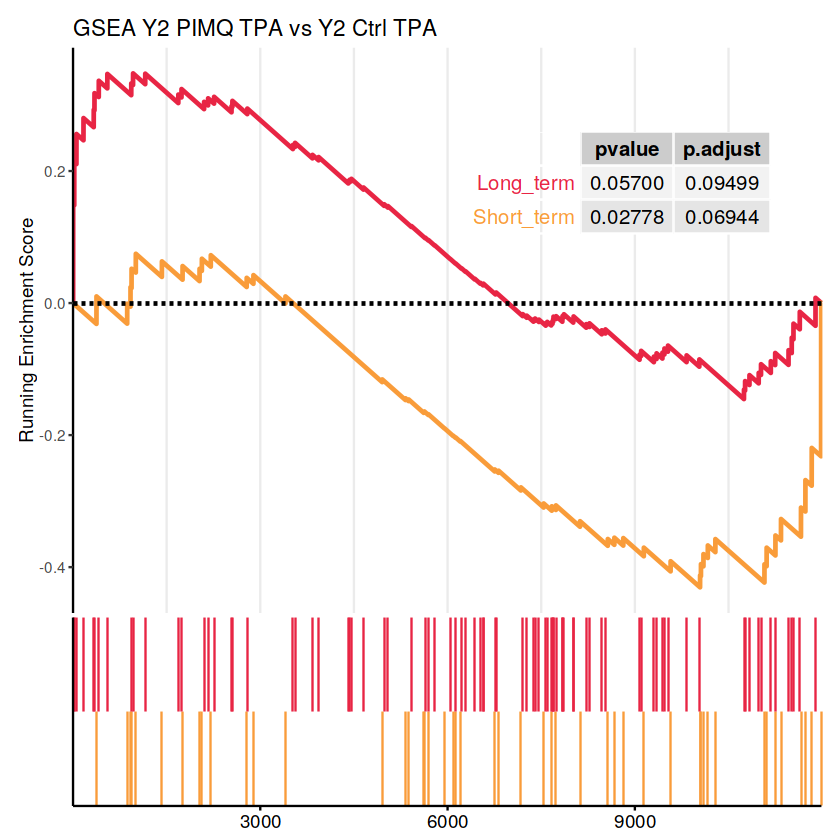

In [12]:
p <- gseaplot2(gseaResults, 
               geneSetID = c("Short_term", "Long_term"),
               title = "GSEA Y2 PIMQ TPA vs Y2 Ctrl TPA",
               color = c("#e82544", "#f99c3a"), subplots = c(1,2),
               pvalue_table = TRUE)

# Agregar línea horizontal en y=0 al primer panel (Enrichment Score)
p[[1]] <- p[[1]] + geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1)

# Mostrar el plot
print(p)

In [13]:
as.data.frame(gseaResults)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Resolved,Resolved,Resolved,585,-0.3126150,-1.573084,5.927986e-06,2.963993e-05,1.871996e-05,2781,"tags=32%, list=23%, signal=26%",Magef1/Ttc32/Amotl1/Daam1/Stx16/Xylt1/Iqgap1/Mitf/Vps35l/Xrn2/Cep68/Eef1aknmt/Usp47/Rbms1/Fcmr/Acvr2a/Ptcd2/Esyt2/Ank3/Cluh/Atp13a4/Cnot2/Plxna1/Ints6/Eefsec/Zfp407/Opa1/Il1r1/Pld1/Pard3/Stk39/Pde4b/Cdca7/Sntb2/Celsr1/Specc1/Mmp2/Zfp644/Pmp22/Prkca/Rasgef1b/Acta2/Chsy1/Tead1/Rgs3/Ptprg/Ccr9/Btbd9/Carmil1/Etv6/Xxylt1/Nfib/Tmem241/Map3k4/Wnk2/Gas7/Ankrd50/Kif16b/Srgap2/Flrt2/Sorcs2/Sdk2/Btbd3/Hhat/Slc38a2/Map2k6/Plpp3/Ube2cbp/Pnpla6/Il20rb/Bcas3/Igf1r/Mtrr/Il1rap/Trio/Sema5a/Tbc1d31/Cobll1/Pum1/Camk1d/Specc1l/Fkbp5/Usp48/Tmem87b/Arntl2/Nfic/Senp6/Tfap2b/Nr4a3/Depdc1b/Kansl1/Pitpnc1/Maml3/Rev1/Fam83b/Tjp1/Smarca2/Ubr3/Zfp280d/Sgms2/Plekha5/Aff1/Sesn3/Lrba/Aldh1l1/Nr3c1/Ch25h/Arhgap25/Pabpc2/Tmem131l/Sox6/Cep152/Kitl/Myc/Il20ra/Garem1/Epha4/Thada/Shtn1/Angptl2/Wwox/Edn1/Kcnj15/Ptprs/Ino80/Aff3/Ano1/Pde4d/Macf1/Bptf/Psd3/Apip/Nfat5/Tsku/Ctu1/Macrod2/Oas3/Cenpf/L3mbtl3/Nfia/Fancc/Prkce/Ttc3/Mex3b/Apbb2/Utp20/Dstyk/Ankhd1/Zfp949/Tasp1/Inpp1/Rnf144b/Utrn/Ccnd1/Creb5/Ednra/Mlh3/Tgfb2/Akap6/Nr4a2/Vav3/Nup210l/Setd4/Has2os/Dglucy/Zfp365/Adgrl3/Pvt1/Tef/Pi15/Prkdc/Adamts9/Cspg4/Prickle2/Adamtsl3/Syne1/Slc25a42/Adcy9/Mnd1-ps/Klf12/Sel1l3/Jakmip2/Trabd2b/Arhgap26/Gipc2/Slc38a6/Ttc8/Dtl/Kcnh1
Short_term,Short_term,Short_term,48,-0.4305389,-1.518544,2.777778e-02,6.944444e-02,4.385965e-02,1945,"tags=27%, list=16%, signal=23%",Slc4a7/Elac1/Map2k6/Sema6d/Ntng2/Nedd9/Vangl1/Macrod2/Armc9/Pi15/Esr1/Klf12/Ccl11
Long_term,Long_term,Long_term,85,0.3478930,1.360841,5.699581e-02,9.499301e-02,5.999559e-02,963,"tags=12%, list=8%, signal=11%",Ptprn2/Rnase2b/Il18/Aim2/C430042M11Rik/Adtrp/Gm4832/Sox5/Robo2/Asl
All_memory,All_memory,All_memory,521,-0.2143907,-1.068956,2.316070e-01,2.363474e-01,1.492720e-01,1991,"tags=20%, list=17%, signal=17%",Pbx1/Sorcs2/Fryl/Thbs2/Btbd3/Slc4a7/Elac1/Myof/Map2k6/Gm26688/Sema3c/Pomgnt2/Slx4ip/Ube2cbp/Sema6d/Sdccag8/Lrrc49/Rrp1b/Ntng2/Cd302/Sema5a/Atp10d/Tubgcp2/Lmnb1/Pdlim5/Atxn7l1/Asph/Ltbp1/Abl2/Maml3/Frmd4a/Piwil2/Mast4/Man2a1/Arhgef10/Zfp280d/Tut7/Nr3c1/Lncpint/Arhgap25/Arhgap18/Jcad/Etv5/Pcnx/Slc23a2/Dip2a/Otud4/Hivep2/Atf7ip/Epas1/Vwa8/Dcun1d2/Mical1/Nedd9/Evl/Vangl1/Ric8b/Map1b/Rabl2/E2f7/Plat/Kics2/Macrod2/Oas3/Fancc/Stox2/Fmnl2/Atg4c/Armc9/Ankhd1/Trps1/Kalrn/Gbe1/Plxna2/Tnfsf18/Nos1ap/Lpp/Cemip/Ccdc63/Akap6/Vav3/Filip1l/Setd4/Nin/Pitpnm3/Pvt1/Pi15/Dock8/Esr1/Nphp4/Spata7/Cyp7b1/Ikzf2/Rassf6/Cald1/Syne1/Klf12/Dock4/Ccl2/Cacna2d3/Gipc2/Gm31763/Dkk3/Ccl11
Unchanged,Unchanged,Unchanged,591,-0.2110982,-1.063354,2.363474e-01,2.363474e-01,1.492720e-01,2253,"tags=21%, list=19%, signal=18%",Pkp4/Slc6a6/Asap1/Rgs3/Tbl1xr1/Zfp326/Evc2/Itpripl2/Ptger2/Mdfic/Etv6/Arid5b/Tiam2/Ankrd50/Acss1/Sipa1l3/Rcor1/Btbd3/Gcc1/Slc4a7/Magi2/Ngf/Slc38a2/Prkx/Map3k7/Prpf4b/Bcas3/Strn/Elf4/Mapre2/Prkaa2/Sema5a/Lekr1/Zscan30/N4bp2l1/Rnf213/Zbtb16/Kat6b/Il18r1/Exoc6/Vwa5a/Ankrd11/Dis3l2/Pak3/Chd1/Afap1l2/Bicral/Nfic/Zbtb39/Hmgcll1/Lgr6/Pitpnc1/Swsap1/Tcf20/Ror1/Hs3st3a1/Fry/Tex10/Lysmd2/4833427F10Rik/Sesn3/Slc4a8/Etv5/Npr3/Slitrk6/Chd7/Trerf1/Il20ra/Zfyve9/Ahnak/Tnrc6c/Nfatc1/Epha4/Atf7ip/Plcb4/Hectd4/Wwox/Col4a6/Aff3/Ano1/Pde4d/Stab1/Arl4c/Dst/Snx24/Cntrob/Kics2/Macrod2/Bcl2l11/Nfia/Prkce/Mzf1/Trub1/Tns1/Plekhm3/Crybg3/Rnf144b/Crppa/Gli2/Creb5/Nos1ap/Lpp/Kcnj2/Dusp9/Igfbp4/Bace1/Nr4a2/Vav3/Ttk/Rasal2/Ap4e1/Mdm1/Snx29/Eml5/Mpdz/Dock8/Efcab1/Cep250/Postn/Prlr/Gipc2/Ccdc57/Nckap5/Klhl17


In [251]:
ggsave('Y2_GSEA.pdf', p, height = 4, width = 6)